In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from imblearn.over_sampling import SMOTE
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Загрузка данных

In [54]:
os.environ["KAGGLEHUB_CACHE"] = "data/kagglehub_cache"

path = kagglehub.dataset_download(
    "uciml/red-wine-quality-cortez-et-al-2009"
)

print("Dataset path:", path)

df = pd.read_csv(path + "/winequality-red.csv")

print(df.head())
print(df.info())
print(df.describe())

Dataset path: data/kagglehub_cache\datasets\uciml\red-wine-quality-cortez-et-al-2009\versions\2
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51      

# Группировка классов

Исходное число классов слишком велико, поэтому необходимо его уменьшить

In [55]:
def quality_group(q):

    if q <= 4:
        return "Low"

    elif q <= 6:
        return "Medium"

    else:
        return "High"


df["quality_group"] = df["quality"].apply(quality_group)

print("\nClass distribution")
print(df["quality_group"].value_counts())



Class distribution
quality_group
Medium    1319
High       217
Low         63
Name: count, dtype: int64


# Стандартизация данных

In [56]:
le = LabelEncoder()

df["quality_encoded"] = le.fit_transform(df["quality_group"])

X = df.drop(["quality", "quality_group", "quality_encoded"], axis=1)
y = df["quality_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train.shape)

Train size: (1279, 11)
Test size: (320, 11)
After SMOTE: (3165, 11)


# Визуализация

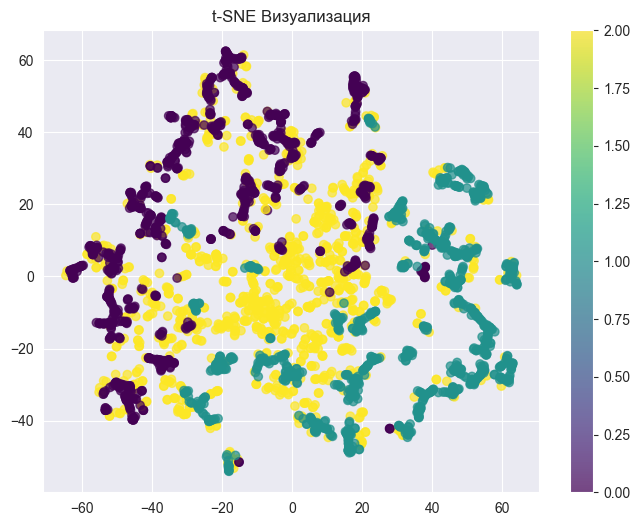

In [9]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_train)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y_train,
    cmap="viridis",
    alpha=0.7
)

plt.title("t-SNE Визуализация")
plt.colorbar(scatter)
plt.show()

# Вклад признаков

In [14]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)
importances = rf.feature_importances_
feature_names = X.columns
idx = np.argsort(importances)[-10:]

print("\nВажность параметров")
for i in idx[::-1]:
    print(f"{feature_names[i]} {round(importances[i], 5)}")


Важность параметров
volatile acidity 0.15473
sulphates 0.14538
alcohol 0.13623
citric acid 0.10565
total sulfur dioxide 0.08303
pH 0.07614
free sulfur dioxide 0.06765
fixed acidity 0.05889
chlorides 0.05846
residual sugar 0.05709


# Random Forest

Модель

In [16]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=6,
                            min_samples_split=10,
                            min_samples_leaf=5,
                            class_weight='balanced',
                            random_state=42)
rf.fit(X_train, y_train)
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

Метрики

Accuracy на train: 0.887
Accuracy на test:  0.759

Метрики по классам
              precision    recall  f1-score   support

        High       0.47      0.79      0.59        43
         Low       0.12      0.23      0.15        13
      Medium       0.93      0.78      0.85       264

    accuracy                           0.76       320
   macro avg       0.51      0.60      0.53       320
weighted avg       0.83      0.76      0.79       320



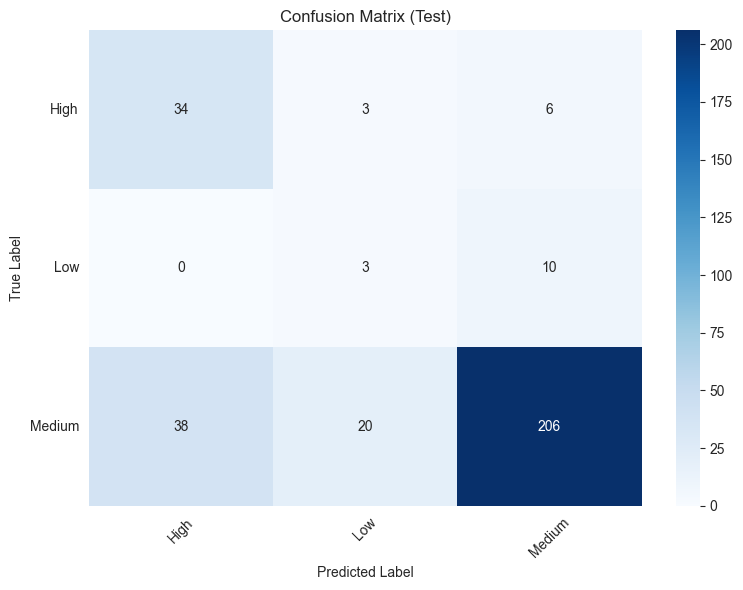

In [17]:
print(f"Accuracy на train: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Accuracy на test:  {accuracy_score(y_test, y_pred_test):.3f}")
print()

print("Метрики по классам")
target_names = le.classes_
print(classification_report(y_test, y_pred_test, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Gradient Boosting Machine on Decision Tree

Модель

In [18]:
gb = GradientBoostingClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )

gb.fit(X_train, y_train)
y_pred_train_gb = gb.predict(X_train)
y_pred_test_gb = gb.predict(X_test)

Метрики

Accuracy на train: 1.000
Accuracy на test:  0.838

Метрики по классам
              precision    recall  f1-score   support

        High       0.56      0.72      0.63        43
         Low       0.20      0.08      0.11        13
      Medium       0.91      0.89      0.90       264

    accuracy                           0.84       320
   macro avg       0.56      0.56      0.55       320
weighted avg       0.83      0.84      0.83       320



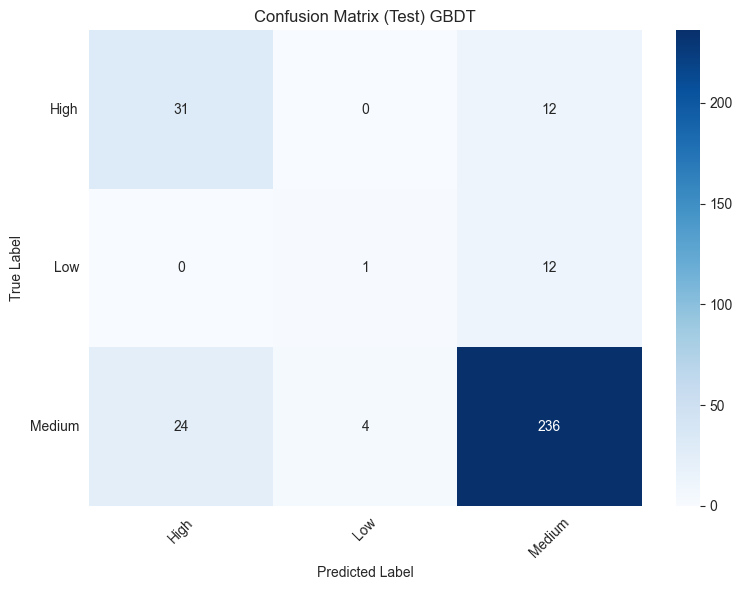

In [20]:
print(f"Accuracy на train: {accuracy_score(y_train, y_pred_train_gb):.3f}")
print(f"Accuracy на test:  {accuracy_score(y_test, y_pred_test_gb):.3f}")
print()

print("Метрики по классам")
target_names = le.classes_
print(classification_report(y_test, y_pred_test_gb, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred_test_gb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test) GBDT')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Support Vector Machine

Модель

In [21]:
svm = SVC(
        C=1.0,
        kernel='rbf',
        gamma='scale',
        class_weight='balanced',
        random_state=42
    )

svm.fit(X_train, y_train)
y_pred_train_svm = svm.predict(X_train)
y_pred_test_svm = svm.predict(X_test)

Метрики

Accuracy на train: 0.886
Accuracy на test:  0.738

Метрики по классам
              precision    recall  f1-score   support

        High       0.43      0.77      0.55        43
         Low       0.16      0.38      0.23        13
      Medium       0.93      0.75      0.83       264

    accuracy                           0.74       320
   macro avg       0.51      0.63      0.54       320
weighted avg       0.83      0.74      0.77       320



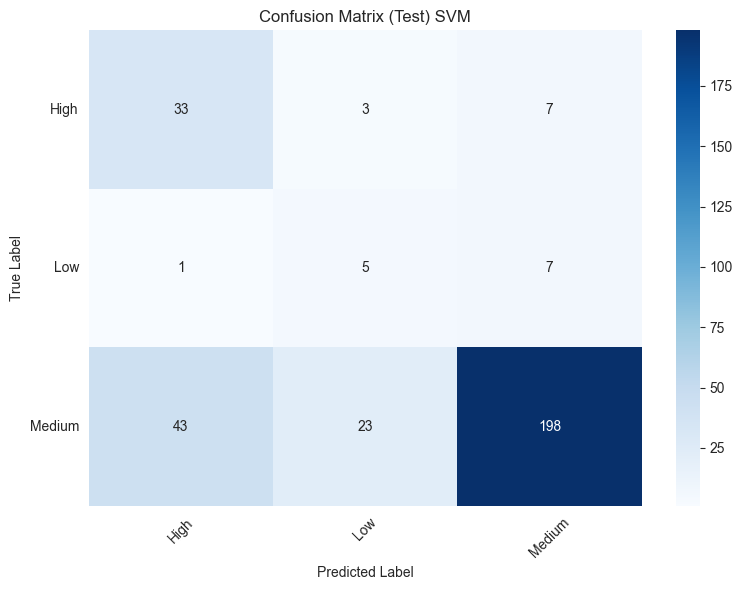

In [22]:
print(f"Accuracy на train: {accuracy_score(y_train, y_pred_train_svm):.3f}")
print(f"Accuracy на test:  {accuracy_score(y_test, y_pred_test_svm):.3f}")
print()

print("Метрики по классам")
target_names = le.classes_
print(classification_report(y_test, y_pred_test_svm, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred_test_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test) SVM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Voting Classifier (GB + SVM)

Модель

In [24]:
ensemble = VotingClassifier(
        estimators=[
            ('gb', GradientBoostingClassifier(
                n_estimators=200, max_depth=6, min_samples_split=10,
                min_samples_leaf=5, random_state=42
            )),
            ('svm', SVC(C=1.0, kernel='rbf', gamma='scale', class_weight='balanced',
                        probability=True, random_state=42))
        ],
        voting='soft'  # soft для вероятностей, требует probability=True в SVC
    )

ensemble.fit(X_train, y_train)
y_pred_train_ensemble = ensemble.predict(X_train)
y_pred_test_ensemble = ensemble.predict(X_test)

Метрики

Accuracy на train: 1.000
Accuracy на test:  0.834

Метрики по классам
              precision    recall  f1-score   support

        High       0.57      0.74      0.65        43
         Low       0.27      0.23      0.25        13
      Medium       0.92      0.88      0.90       264

    accuracy                           0.83       320
   macro avg       0.59      0.62      0.60       320
weighted avg       0.84      0.83      0.84       320



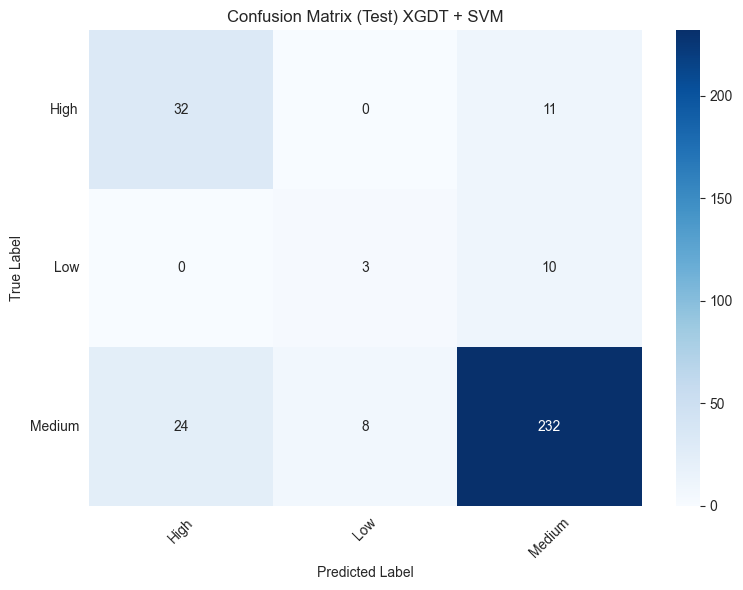

In [26]:
print(f"Accuracy на train: {accuracy_score(y_train, y_pred_train_ensemble):.3f}")
print(f"Accuracy на test:  {accuracy_score(y_test, y_pred_test_ensemble):.3f}")
print()

print("Метрики по классам")
target_names = le.classes_
print(classification_report(y_test, y_pred_test_ensemble, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred_test_ensemble)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test) XGDT + SVM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Кластеризация

Объединение выборок

In [60]:
X_cluster = np.vstack([X_train, X_test])
print("X_cluster shape:", X_cluster.shape)

X_cluster shape: (3485, 11)


Кластеризация GMM, число кластеров равно числу сгруппированных классов

In [61]:
gmm = GaussianMixture(n_components=3, random_state=42, n_init=20)
gmm_labels = gmm.fit_predict(X_cluster)

# Метрики (на полном датасете)
sil_gmm = silhouette_score(X_cluster, gmm_labels)
db_gmm = davies_bouldin_score(X_cluster, gmm_labels)

print(f"GMM (k=3): Silhouette={sil_gmm:.3f}, Davies-Bouldin={db_gmm:.3f}")
print("Распределение кластеров:", np.bincount(gmm_labels))

GMM (k=3): Silhouette=0.103, Davies-Bouldin=2.908
Распределение кластеров: [ 749 2046  690]


PCA визуализация результатов

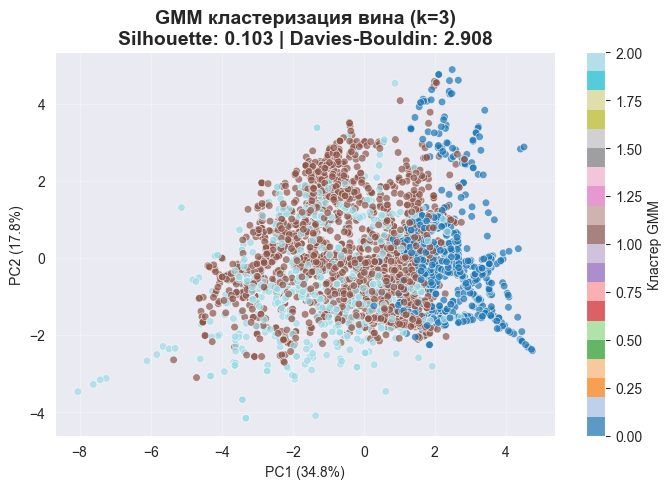

In [62]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=gmm_labels, cmap='tab20', s=30, alpha=0.7, edgecolors='w', linewidth=0.5)
plt.colorbar(scatter, label='Кластер GMM')
plt.title(f'GMM кластеризация вина (k=3)\nSilhouette: {sil_gmm:.3f} | Davies-Bouldin: {db_gmm:.3f}',
          fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()